# House Price Prediction — Regression Analysis

## Objective

The objective of this project is to build a regression model to predict house prices based on relevant features in the dataset. The project demonstrates how linear regression can be used to understand the relationship between housing features and house prices.

## Dataset

The House Price Prediction dataset is used to analyze the relationship between the selected input feature(s) and house prices and to build a predictive regression model.

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Scikit-learn
* Jupyter Notebook

## Workflow

1. Load and inspect the house price dataset
2. Understand the structure and characteristics of the data
3. Perform basic data preprocessing
4. Select the relevant features and target variable
5. Split the data into training and testing sets
6. Build a Linear Regression model
7. Train the model using the training data
8. Make predictions on the test data
9. Evaluate the model performance
10. Visualize the relationship between actual and predicted values

## Conclusion

A Linear Regression model was developed to predict house prices using the available housing data. The model was evaluated using appropriate performance metrics and visualizations to understand its predictive performance and the relationship between the selected features and house prices.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (506, 14)


In [ ]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [ ]:
X = df[["rm"]]
y = df["medv"]

print("X (Independent Variable):")
print(X.head())

print("\ny (Dependent Variable):")
print(y.head())

X (Independent Variable):
      rm
0  6.575
1  6.421
2  7.185
3  6.998
4  7.147

y (Dependent Variable):
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64


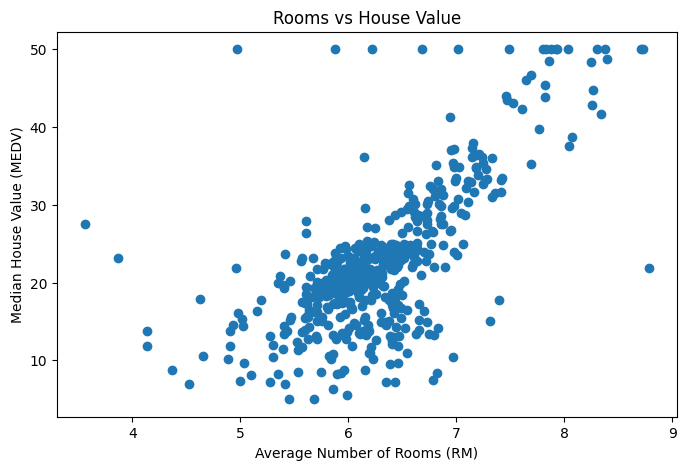

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Rooms vs House Value")

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (404, 1)
Testing data: (102, 1)


In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[23.73238293 26.92950201 19.68456842 20.45112913 22.61993506 22.45166563
 19.03953562 21.47009399 21.98425056 20.09589368]


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.3707569232254778


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 46.144775347317264


In [ ]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 9.348301406497727
Intercept: -36.24631889813795


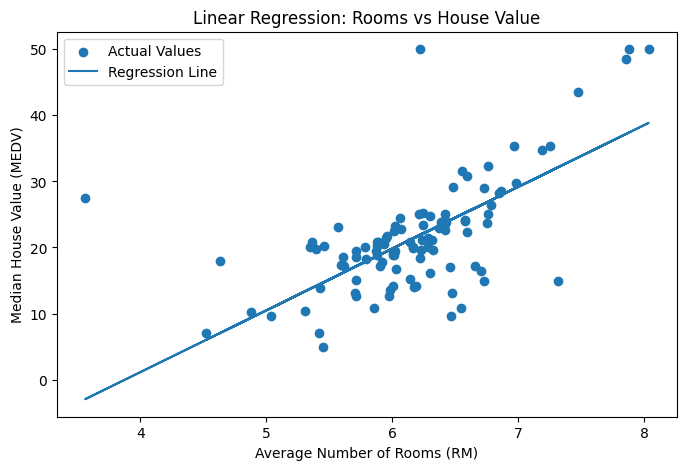

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual Values")
plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Linear Regression: Rooms vs House Value")
plt.legend()

plt.show()

NameError: name 'X_sorted' is not defined

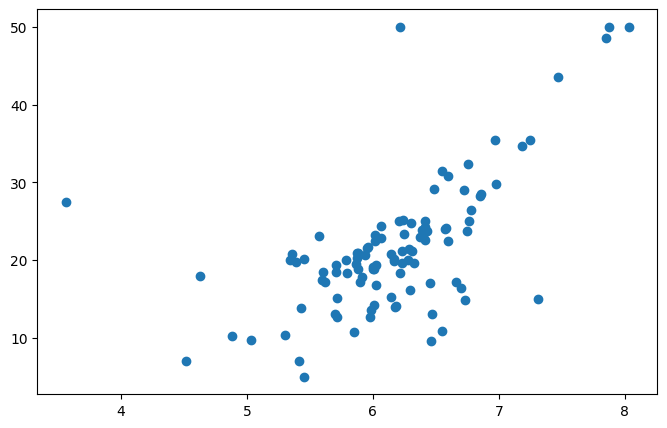

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test["rm"], y_test, label="Actual Values")

plt.plot(
    X_sorted["rm"],
    y_pred_sorted,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Simple Linear Regression: Rooms vs House Value")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np

sorted_indices = np.argsort(X_test["rm"].values)

X_sorted = X_test.iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

print("Sorted values created successfully!")

Sorted values created successfully!


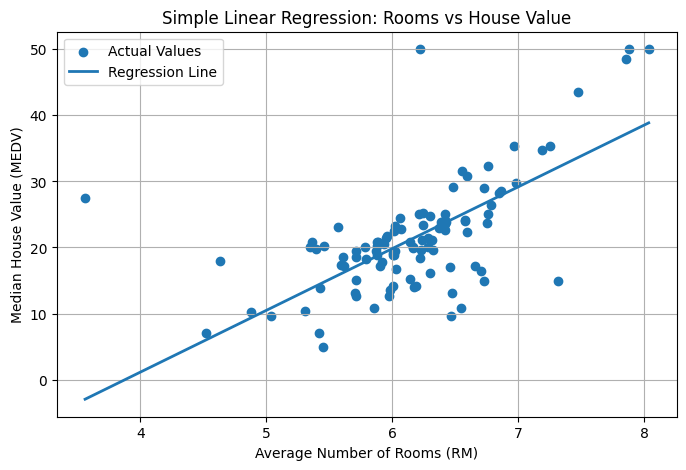

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test["rm"], y_test, label="Actual Values")

plt.plot(
    X_sorted["rm"],
    y_pred_sorted,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Simple Linear Regression: Rooms vs House Value")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("----- FINAL RESULTS -----")
print("R² Score:", r2)
print("Mean Squared Error:", mse)
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nRegression Equation:")
print(f"MEDV = {model.intercept_:.4f} + ({model.coef_[0]:.4f} × RM)")

----- FINAL RESULTS -----
R² Score: 0.3707569232254778
Mean Squared Error: 46.144775347317264
Coefficient: 9.348301406497727
Intercept: -36.24631889813795

Regression Equation:
MEDV = -36.2463 + (9.3483 × RM)
